# Reinforcement Learning for *Take Six!* (6 nimmt!)

**Course project – Reinforcement Learning**

## Team
- Tianyu CAO (tianyu.cao@polytechnique.edu)
- Yuguang YAO (yuguang.yao@polytechnique.edu)
- Yuran ZOU (yuran.zou@polytechnique.edu)

## Project overview
In this project, we model the board game **Take Six!** as a custom reinforcement learning environment and investigate how **state representation** and **opponent distribution** affect policy performance.

Our work proceeds in three stages:

1. We build a reproducible Gymnasium-style environment for the game, including controlled randomness and rule validation.
2. We compare several RL approaches, including **PPO**, **DQN**, **QRDQN**, and **Heuristic+RL**, and identify **QRDQN** as the strongest baseline in the original environment.
3. We study the role of representation design through ablations and introduce a **Row DeepSets** encoder to better handle row symmetry. We then extend the environment by replacing random opponents with stronger frozen policies and analyze cross-environment generalization.

## Main takeaways
- In this task, **value-based methods outperform PPO-style baselines**.
- The most important performance gains come from **representation design**, especially continuous normalization and row symmetry handling.
- Stronger fixed opponents induce a different optimum: policies trained in the original environment do not transfer well, and retraining in the harder environment is necessary to recover performance.

## Repository guide
This notebook is a lightweight entry point for:
- demonstrating the environments,
- loading and visualizing the final results,
- showing how to reproduce the main experiments.

The heavy training code remains in the `.py` scripts under `scripts/`, while the environments are implemented under `src/sixnimmt_env/`.

## 1. Setup

We first import the required libraries and check that the repository is accessible from the notebook.

This project follows a `src/` layout:
- environment code is under `src/sixnimmt_env/`
- experiment scripts are under `scripts/`
- trained checkpoints are under `checkpoints/`
- summarized results are under `results/`

The notebook does **not** retrain models by default. Instead, it loads the final outputs and demonstrates how the environments and evaluation pipeline work.

In [1]:
# Optional:
# If needed, install the package in editable mode from the repository root:
# !pip install -e .

In [2]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ROOT = Path(".").resolve()
ROOT

WindowsPath('D:/课件及作业/作业/X/CSC_52081_EP-Reinforcement-Learning/sixnimmt')

In [4]:
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [5]:
required_paths = [
    "src/sixnimmt_env/core.py",
    "src/sixnimmt_env/env.py",
    "src/sixnimmt_env/env_fixed_opponents.py",
    "src/sixnimmt_env/__init__.py",
    "checkpoints/demo_models/qrdqn_rowdeepsets_old_best/best_model.pt",
    "checkpoints/demo_models/qrdqn_rowdeepsets_fixedopp_best/best_model.pt",
    "results/old_env/all_methods_5seed_summary.csv",
    "results/new_env/qrdqn_rowdeepsets_fixedopp_5seed_aggregate.json",
    "results/cross_eval/summary_2x2.csv",
]

missing = [p for p in required_paths if not Path(p).exists()]
if missing:
    print("Missing files:")
    for p in missing:
        print(" -", p)
else:
    print("All required paths found.")

All required paths found.


## 2. Environment demo

We use two environments in this project:

### Original environment
- the learning agent is `player 0`
- the other three players are random opponents
- reward is defined as  
$$
  r_t = -\text{agent penalty at step } t
$$

### Harder fixed-opponent environment
- the game rules and reward stay the same
- the three random opponents are replaced by stronger **frozen policies**
- specifically, we use:
  - PPO(seed1)
  - PPO(seed2)
  - Heuristic+PPO(seed1)

This allows us to study how the learned policy changes when the opponent distribution becomes harder.

In [6]:
from sixnimmt_env import SixQuiPrendEnv, SixQuiPrendEnvFixedOpponents
from sixnimmt_env.opponent_policies import (
    FrozenMaskablePPOPolicy,
    FrozenHeuristicPPOPolicy,
)

In [7]:
env = SixQuiPrendEnv()
obs, info = env.reset(seed=42)

print("Observation keys:", list(obs.keys()))
obs

Observation keys: ['player_hand', 'last_value_of_rows', 'length_of_rows', 'table_bulls']


{'player_hand': [11, 33, 46, 53, 60, 66, 69, 83, 91, 99],
 'last_value_of_rows': [56, 89, 13, 37],
 'length_of_rows': [1, 1, 1, 1],
 'table_bulls': [1, 1, 1, 1]}

In [8]:
mask = env.action_masks()
print("Action mask:", mask)

valid_actions = [i for i, ok in enumerate(mask) if ok]
print("Valid actions:", valid_actions)

action = valid_actions[0]
next_obs, reward, terminated, truncated, info = env.step(action)

print("Chosen action:", action)
print("Reward:", reward)
print("Terminated:", terminated, "| Truncated:", truncated)

Action mask: [True, True, True, True, True, True, True, True, True, True]
Valid actions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Chosen action: 0
Reward: -1
Terminated: False | Truncated: False


In [9]:
env.render()


--- TABLE ---
Row 0: [56, 64, 80] | Bulls=5
Row 1: [11] | Bulls=5
Row 2: [13] | Bulls=1
Row 3: [37, 50] | Bulls=4

--- AGENT HAND ---
[33, 46, 53, 60, 66, 69, 83, 91, 99]

--- SCORES ---
Player 0: 1
Player 1: 0
Player 2: 0
Player 3: 0


The original environment exposes a compact structured observation:
- `player_hand`
- `last_value_of_rows`
- `length_of_rows`
- `table_bulls`

The action space is fixed to size 10, while legality is handled through `action_masks()`, since the hand size decreases over time.

In [10]:
ppo1 = FrozenMaskablePPOPolicy.from_run_dir("checkpoints/frozen_opponents/ppo_seed1")
ppo2 = FrozenMaskablePPOPolicy.from_run_dir("checkpoints/frozen_opponents/ppo_seed2")
heur1 = FrozenHeuristicPPOPolicy.from_run_dir("checkpoints/frozen_opponents/heuristic_seed1")

env_fixed = SixQuiPrendEnvFixedOpponents(
    opponent_policies=[ppo1, ppo2, heur1],
    opponent_name="ppo1_ppo2_heur1",
)

obs_fixed, info_fixed = env_fixed.reset(seed=42)

print("Observation keys:", list(obs_fixed.keys()))
obs_fixed

Observation keys: ['player_hand', 'last_value_of_rows', 'length_of_rows', 'table_bulls']


{'player_hand': [11, 33, 46, 53, 60, 66, 69, 83, 91, 99],
 'last_value_of_rows': [56, 89, 13, 37],
 'length_of_rows': [1, 1, 1, 1],
 'table_bulls': [1, 1, 1, 1]}

In [11]:
mask_fixed = env_fixed.action_masks()
print("Action mask:", mask_fixed)

valid_actions_fixed = [i for i, ok in enumerate(mask_fixed) if ok]
action_fixed = valid_actions_fixed[0]

next_obs_fixed, reward_fixed, terminated_fixed, truncated_fixed, info_fixed = env_fixed.step(action_fixed)

print("Chosen action:", action_fixed)
print("Reward:", reward_fixed)
print("Terminated:", terminated_fixed, "| Truncated:", truncated_fixed)

Action mask: [True, True, True, True, True, True, True, True, True, True]
Chosen action: 0
Reward: -1
Terminated: False | Truncated: False


In [12]:
env_fixed.render()


--- TABLE ---
Row 0: [56, 73, 77, 97] | Bulls=8
Row 1: [11] | Bulls=5
Row 2: [13] | Bulls=1
Row 3: [37] | Bulls=1

--- AGENT HAND ---
[33, 46, 53, 60, 66, 69, 83, 91, 99]

--- SCORES ---
Player 0: 1
Player 1: 0
Player 2: 0
Player 3: 0


Both environments share the same interface for the learning agent:
- same observation keys,
- same action masking mechanism,
- same reward definition.

The only difference is the opponent distribution:
- random opponents in the original environment,
- stronger frozen opponents in the harder environment.

This is important because it lets us study adaptation to stronger opponents without changing the core game mechanics.

## 3. Main results in the original environment

We first summarize the experiments conducted in the **original random-opponent environment**.

The main comparison includes:
- PPO
- DQN
- QRDQN
- Heuristic+RL
- QRDQN + Row DeepSets

Our main conclusion in the original environment is:

- PPO is not the strongest choice for this task,
- among DQN and QRDQN, QRDQN is stronger,
- adding the **Row DeepSets** encoder on top of QRDQN gives the best final result.

In [33]:
old_methods = pd.read_csv("results/old_env/all_methods_5seed_summary.csv")

rowdeepsets = pd.read_csv("results/old_env/qrdqn_rowdeepsets_5seed_summary.csv")
rowdeepsets = rowdeepsets.assign(
    method="qrdqn_rowdeepsets",
    wrapper_or_features="row_deepsets",
)

common_cols = [col for col in old_methods.columns if col in rowdeepsets.columns]
old_methods = pd.concat(
    [old_methods, rowdeepsets[common_cols]],
    ignore_index=True,
    sort=False,
 )

old_methods

,method,seed,run_name,run_dir,train_steps,wrapper_or_features,eval_mean_return,eval_std_return,eval_min_return,eval_max_return,aux_1,aux_2
0,ppo,0,ppo_sorted_addobservation_100000_seed0,outputs/ppo_runs/ppo_sorted_addobservation_100...,100000.0,sorted_addobservation,-10.056,7.364704,-42.0,0.0,-8.305,-8.760
1,ppo,1,ppo_sorted_addobservation_100000_seed1,outputs/ppo_runs/ppo_sorted_addobservation_100...,100000.0,sorted_addobservation,-8.704,6.535930,-40.0,0.0,-7.650,-7.385
2,ppo,2,ppo_sorted_addobservation_100000_seed2,outputs/ppo_runs/ppo_sorted_addobservation_100...,100000.0,sorted_addobservation,-8.870,6.446480,-40.0,0.0,-8.430,-8.550
3,ppo,3,ppo_sorted_addobservation_100000_seed3,outputs/ppo_runs/ppo_sorted_addobservation_100...,100000.0,sorted_addobservation,-8.973,6.659750,-41.0,0.0,-8.775,-9.080
4,ppo,4,ppo_sorted_addobservation_100000_seed4,outputs/ppo_runs/ppo_sorted_addobservation_100...,100000.0,sorted_addobservation,-8.723,6.709864,-42.0,0.0,-8.670,-8.570
5,dqn,0,dqn_cont_sort_diff_100000_seed0,outputs/value_runs/dqn_cont_sort_diff_100000_s...,100000.0,continuous+sort+diff,-8.282,7.433470,-37.0,0.0,-7.835,-8.415
6,dqn,1,dqn_cont_sort_diff_100000_seed1,outputs/value_runs/dqn_cont_sort_diff_100000_s...,100000.0,continuous+sort+diff,-7.774,6.796685,-34.0,0.0,-7.545,-7.545
7,dqn,2,dqn_cont_sort_diff_100000_seed2,outputs/value_runs/dqn_cont_sort_diff_100000_s...,100000.0,continuous+sort+diff,-8.132,7.055961,-43.0,0.0,-7.365,-7.365
8,dqn,3,dqn_cont_sort_diff_100000_seed3,outputs/value_runs/dqn_cont_sort_diff_100000_s...,100000.0,continuous+sort+diff,-8.236,7.075048,-42.0,0.0,-7.710,-7.710
9,dqn,4,dqn_cont_sort_diff_100000_seed4,outputs/value_runs/dqn_cont_sort_diff_100000_s...,100000.0,continuous+sort+diff,-8.489,7.217193,-37.0,0.0,-7.445,-7.445


In [34]:
print(old_methods.columns.tolist())

['method', 'seed', 'run_name', 'run_dir', 'train_steps', 'wrapper_or_features', 'eval_mean_return', 'eval_std_return', 'eval_min_return', 'eval_max_return', 'aux_1', 'aux_2']


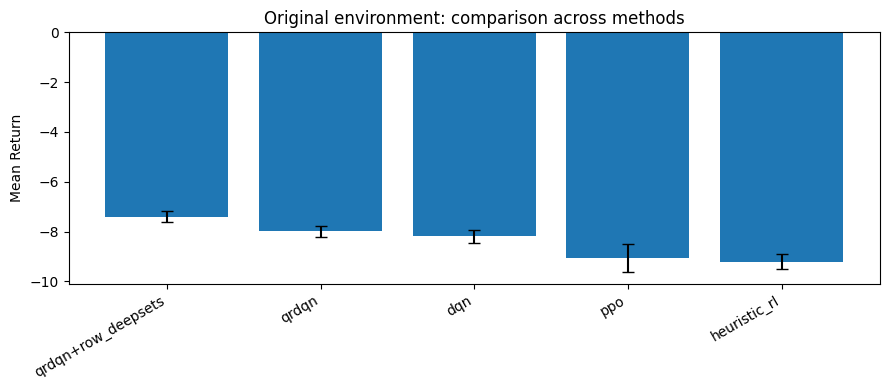

,method_display,mean_return,std_return
4,qrdqn+row_deepsets,-7.3976,0.235880
3,qrdqn,-7.9886,0.226251
0,dqn,-8.1826,0.262739
2,ppo,-9.0652,0.564769
1,heuristic_rl,-9.2172,0.296275


In [35]:
method_col = "method"
value_col = "eval_mean_return"

method_name_map = {
    "ppo": "ppo",
    "dqn": "dqn",
    "qrdqn": "qrdqn",
    "heuristic_rl": "heuristic_rl",
    "qrdqn_rowdeepsets": "qrdqn+row_deepsets",
}

plot_df = (
    old_methods.assign(method_display=old_methods[method_col].map(method_name_map).fillna(old_methods[method_col]))
    .groupby("method_display", as_index=False)
    .agg(
        mean_return=(value_col, "mean"),
        std_return=(value_col, "std"),
    )
    .sort_values("mean_return", ascending=False)
 )

plt.figure(figsize=(9, 4))
plt.bar(
    plot_df["method_display"],
    plot_df["mean_return"],
    yerr=plot_df["std_return"].fillna(0.0),
    capsize=4,
 )
plt.ylabel("Mean Return")
plt.title("Original environment: comparison across methods")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plot_df

In this setting, more positive returns are better because the reward is defined as the negative of the penalty.

The original-environment experiments show that:
- PPO is not the strongest choice for this task,
- QRDQN is stronger than DQN,
- and the best final result is obtained by **QRDQN + Row DeepSets**.

In [16]:
with open("results/old_env/qrdqn_rowdeepsets_5seed_aggregate.json", "r") as f:
    old_best = json.load(f)

old_best

{'num_runs': 5,
 'eval_mean_return_mean': -7.397600078582764,
 'eval_mean_return_std_across_seeds': 0.2109772328812072,
 'eval_std_return_mean': 6.38247709274292,
 'best_eval_mean_return': -7.056000232696533,
 'worst_eval_mean_return': -7.690999984741211}

In [17]:
old_best_summary = pd.DataFrame([
    {
        "setting": "old_env / QRDQN + Row DeepSets",
        "mean_return": old_best.get("eval_mean_return_mean", np.nan),
        "std_across_seeds": old_best.get("eval_mean_return_std_across_seeds", np.nan),
        "best_seed_return": old_best.get("best_eval_mean_return", np.nan),
        "worst_seed_return": old_best.get("worst_eval_mean_return", np.nan),
    }
])

old_best_summary

,setting,mean_return,std_across_seeds,best_seed_return,worst_seed_return
0,old_env / QRDQN + Row DeepSets,-7.3976,0.210977,-7.056,-7.691


This original-environment result serves as our **main reference point**.

From here, we ask two follow-up questions:

1. **Why** does the final method perform better?
2. What happens if we change the opponent distribution and make the environment harder?

## 4. Ablation study: why representation matters

A central finding of this project is that the largest gains do not come only from switching RL algorithms, but from improving the **state representation**.

We systematically studied three representation choices:

- **continuous normalization**
- **row sorting**
- **extra difference features** (`add_diff`)

This lets us separate:
- the contribution of each feature design choice,
- and their interactions.

In [18]:
abl = pd.read_csv("results/ablation/ablation_aggregate.csv")
abl.head()

,method,config_name,continuous_obs,sort_rows,add_diff,num_runs,eval_mean_return_mean,eval_mean_return_std_across_seeds,eval_std_return_mean,eval_min_return_mean,eval_max_return_mean,best_eval_mean_return,worst_eval_mean_return
0,qrdqn,cont1_sort1_diff1,True,True,True,5,-7.6368,0.169802,6.338276,-37.4,0.0,-7.457,-7.896
1,qrdqn,cont1_sort1_diff0,True,True,False,5,-8.0812,0.130414,6.620265,-39.4,0.0,-7.888,-8.267
2,qrdqn,cont1_sort0_diff1,True,False,True,5,-8.4358,0.223785,6.573020,-37.6,0.0,-8.143,-8.817
3,qrdqn,cont1_sort0_diff0,True,False,False,5,-8.5924,0.194403,6.683241,-38.6,0.0,-8.353,-8.891
4,qrdqn,cont0_sort1_diff0,False,True,False,5,-8.9208,0.246240,7.000343,-40.0,0.0,-8.666,-9.346


In [19]:
print(abl.columns.tolist())

['method', 'config_name', 'continuous_obs', 'sort_rows', 'add_diff', 'num_runs', 'eval_mean_return_mean', 'eval_mean_return_std_across_seeds', 'eval_std_return_mean', 'eval_min_return_mean', 'eval_max_return_mean', 'best_eval_mean_return', 'worst_eval_mean_return']


In [20]:
main_eff = pd.read_csv("results/ablation/ablation_main_effects.csv")
main_eff

,method,factor,mean_return_when_on,mean_return_when_off,delta_on_minus_off,num_configs_on,num_configs_off
0,qrdqn,continuous_obs,-8.18655,-9.86765,1.6811,4,4
1,qrdqn,sort_rows,-8.58240,-9.47180,0.8894,4,4
2,qrdqn,add_diff,-9.09480,-8.95940,-0.1354,4,4


In [21]:
pair_eff = pd.read_csv("results/ablation/ablation_pairwise_interactions.csv")
pair_eff

,method,factor_a,factor_b,mean_11,mean_10,mean_01,mean_00,interaction_term
0,qrdqn,continuous_obs,sort_rows,-7.8590,-8.5141,-9.3058,-10.4295,-0.4686
1,qrdqn,continuous_obs,add_diff,-8.0363,-8.3368,-10.1533,-9.5820,0.8718
2,qrdqn,sort_rows,add_diff,-8.6638,-8.5010,-9.5258,-9.4178,-0.0548


In [22]:
print(main_eff.columns.tolist())

['method', 'factor', 'mean_return_when_on', 'mean_return_when_off', 'delta_on_minus_off', 'num_configs_on', 'num_configs_off']


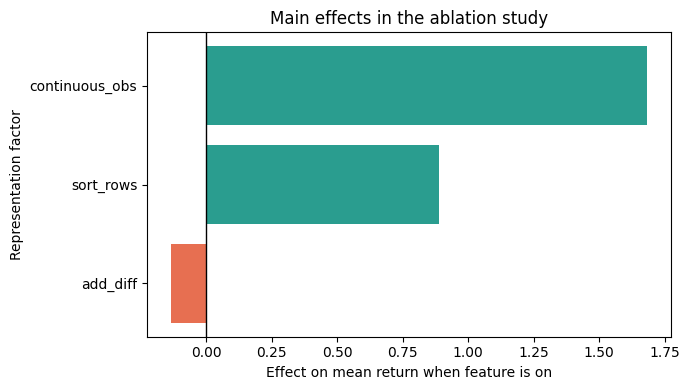

,factor,delta_on_minus_off,mean_return_when_on,mean_return_when_off
2,add_diff,-0.1354,-9.09480,-8.95940
1,sort_rows,0.8894,-8.58240,-9.47180
0,continuous_obs,1.6811,-8.18655,-9.86765


In [23]:
factor_col = "factor"
effect_col = "delta_on_minus_off"

plot_main_eff = main_eff.sort_values(effect_col)
colors = ["#2a9d8f" if value >= 0 else "#e76f51" for value in plot_main_eff[effect_col]]

plt.figure(figsize=(7, 4))
plt.barh(plot_main_eff[factor_col], plot_main_eff[effect_col], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Effect on mean return when feature is on")
plt.ylabel("Representation factor")
plt.title("Main effects in the ablation study")
plt.tight_layout()
plt.show()

plot_main_eff[[factor_col, effect_col, "mean_return_when_on", "mean_return_when_off"]]

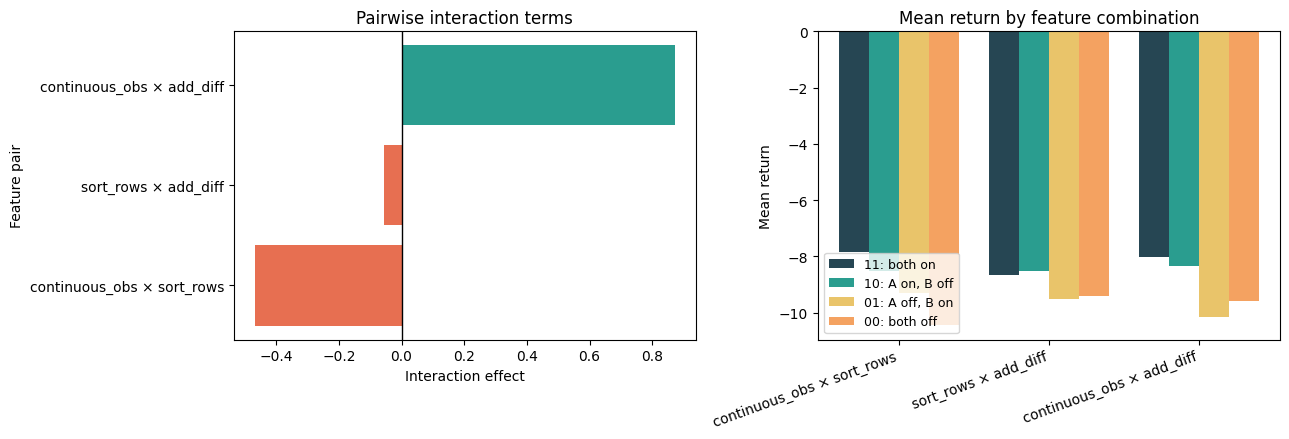

,pair,interaction_term,mean_11,mean_10,mean_01,mean_00
0,continuous_obs × sort_rows,-0.4686,-7.8590,-8.5141,-9.3058,-10.4295
2,sort_rows × add_diff,-0.0548,-8.6638,-8.5010,-9.5258,-9.4178
1,continuous_obs × add_diff,0.8718,-8.0363,-8.3368,-10.1533,-9.5820


In [24]:
pair_plot = pair_eff.copy()
pair_plot["pair"] = pair_plot["factor_a"] + " × " + pair_plot["factor_b"]
pair_plot = pair_plot.sort_values("interaction_term")

interaction_colors = [
    "#2a9d8f" if value >= 0 else "#e76f51"
    for value in pair_plot["interaction_term"]
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].barh(
    pair_plot["pair"],
    pair_plot["interaction_term"],
    color=interaction_colors,
 )
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Pairwise interaction terms")
axes[0].set_xlabel("Interaction effect")
axes[0].set_ylabel("Feature pair")

bar_positions = np.arange(len(pair_plot))
bar_width = 0.2
condition_cols = ["mean_11", "mean_10", "mean_01", "mean_00"]
condition_labels = ["11: both on", "10: A on, B off", "01: A off, B on", "00: both off"]
condition_colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261"]

for index, (col, label, color) in enumerate(zip(condition_cols, condition_labels, condition_colors)):
    axes[1].bar(
        bar_positions + (index - 1.5) * bar_width,
        pair_plot[col],
        width=bar_width,
        label=label,
        color=color,
    )

axes[1].set_xticks(bar_positions)
axes[1].set_xticklabels(pair_plot["pair"], rotation=20, ha="right")
axes[1].set_title("Mean return by feature combination")
axes[1].set_ylabel("Mean return")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

pair_plot[["pair", "interaction_term", "mean_11", "mean_10", "mean_01", "mean_00"]]

The ablation results support the following interpretation:

- **continuous normalization** is the most important single improvement,
- **row sorting** is also consistently useful,
- **add_diff** is less reliable in isolation, but its value depends on what other representation choices are already present.

The pairwise effects refine this picture:

- **continuous_obs x add_diff** is the strongest positive interaction, suggesting that difference features become more useful once the inputs are properly normalized,
- **continuous_obs x sort_rows** is slightly negative, which suggests some overlap in the benefits they provide,
- **sort_rows x add_diff** is close to zero, so their interaction is weak.

This suggests that the model benefits strongly from:
1. a better-scaled numeric representation,
2. a better treatment of the row structure,
3. and a representation design in which some features only become effective after the base encoding has been improved.

This directly motivates our final architectural step.

The rows in the game are not arbitrary independent features:
they form a small structured set, and their order is not inherently meaningful.

The ablation results show both a strong main effect for `sort_rows` and only limited gains from manually adding more local difference features unless the rest of the representation is already well designed.

This suggests that the real issue is not just feature engineering in isolation, but **row symmetry** and the need for a representation that handles row permutations more naturally.

Instead of relying only on hand-crafted sorting, we therefore introduce a more principled encoder:
**Row DeepSets**.

### Row DeepSets intuition

Each row is represented by a compact tuple of features:
- tail value,
- row length,
- row bulls.

A shared row encoder is applied to all four rows, and the row embeddings are then aggregated using permutation-friendly pooling (mean and max).

This provides a cleaner inductive bias than hand-crafted row ordering, while remaining lightweight and fully compatible with the QRDQN backbone.

In summary, the original-environment experiments support the following message:

> Better performance in this task comes mainly from **representation design** and **symmetry handling**, not just from choosing a more sophisticated RL algorithm.

## 5. Harder environment: frozen stronger opponents

To make the task more challenging, we construct a second environment in which the three random opponents are replaced by stronger **frozen policies**:

- PPO(seed1)
- PPO(seed2)
- Heuristic+PPO(seed1)

Importantly:
- the game mechanics stay the same,
- the reward stays the same,
- the agent interface stays the same.

Only the **opponent distribution** changes.

In [25]:
new_env_summary = pd.read_csv("results/new_env/qrdqn_rowdeepsets_fixedopp_5seed_summary.csv")
new_env_summary

,seed,run_name,mean_return,std_return,min_return,max_return,mean_penalty
0,0,qrdqn_rowdeepsets_fixedopp_seed0,-6.703,6.690799,-36.0,0.0,6.703
1,1,qrdqn_rowdeepsets_fixedopp_seed1,-7.104,6.464610,-39.0,0.0,7.104
2,2,qrdqn_rowdeepsets_fixedopp_seed2,-6.670,6.303895,-38.0,0.0,6.670
3,3,qrdqn_rowdeepsets_fixedopp_seed3,-6.849,6.325678,-32.0,0.0,6.849
4,4,qrdqn_rowdeepsets_fixedopp_seed4,-6.744,6.399880,-38.0,0.0,6.744


In [26]:
with open("results/new_env/qrdqn_rowdeepsets_fixedopp_5seed_aggregate.json", "r") as f:
    new_best = json.load(f)

new_best

{'aggregate': {'run_prefix': 'qrdqn_rowdeepsets_fixedopp',
  'num_runs': 5,
  'seeds': [0, 1, 2, 3, 4],
  'mean_of_mean_returns': -6.814000034332276,
  'std_across_seeds': 0.15702357794731062,
  'best_seed_return': -6.670000076293945,
  'worst_seed_return': -7.104000091552734,
  'best_seed': 2,
  'worst_seed': 1},
 'per_seed': [{'seed': 0,
   'run_name': 'qrdqn_rowdeepsets_fixedopp_seed0',
   'mean_return': -6.703000068664551,
   'std_return': 6.690798759460449,
   'min_return': -36.0,
   'max_return': 0.0,
   'mean_penalty': 6.703000068664551},
  {'seed': 1,
   'run_name': 'qrdqn_rowdeepsets_fixedopp_seed1',
   'mean_return': -7.104000091552734,
   'std_return': 6.4646100997924805,
   'min_return': -39.0,
   'max_return': 0.0,
   'mean_penalty': 7.104000091552734},
  {'seed': 2,
   'run_name': 'qrdqn_rowdeepsets_fixedopp_seed2',
   'mean_return': -6.670000076293945,
   'std_return': 6.303895473480225,
   'min_return': -38.0,
   'max_return': 0.0,
   'mean_penalty': 6.670000076293945},

In [27]:
old_mean = old_best.get("eval_mean_return_mean", old_best.get("mean_of_mean_returns", np.nan))
old_std = old_best.get("eval_mean_return_std_across_seeds", old_best.get("std_across_seeds", np.nan))

new_agg = new_best.get("aggregate", new_best)
new_mean = new_agg.get("mean_of_mean_returns", new_agg.get("eval_mean_return_mean", np.nan))
new_std = new_agg.get("std_across_seeds", new_agg.get("eval_mean_return_std_across_seeds", np.nan))

compare_best = pd.DataFrame([
    {
        "setting": "old_env / QRDQN + Row DeepSets",
        "mean_return": old_mean,
        "std_across_seeds": old_std,
    },
    {
        "setting": "fixed_opp_env / QRDQN + Row DeepSets",
        "mean_return": new_mean,
        "std_across_seeds": new_std,
    },
])

compare_best

,setting,mean_return,std_across_seeds
0,old_env / QRDQN + Row DeepSets,-7.3976,0.210977
1,fixed_opp_env / QRDQN + Row DeepSets,-6.8140,0.157024


The fixed-opponent environment is not directly comparable in absolute difficulty to the original one, since the opponent distribution is different.

What matters here is not whether the raw number is larger or smaller across environments, but whether a policy trained in one environment transfers well to the other.

In [28]:
cross_2x2 = pd.read_csv("results/cross_eval/summary_2x2.csv")
cross_2x2

,train_env,test_env,mean_return
0,old_env,old_env,-7.3976
1,old_env,new_fixedopp_env,-8.5408
2,new_fixedopp_env,old_env,-7.8450
3,new_fixedopp_env,new_fixedopp_env,-6.8140


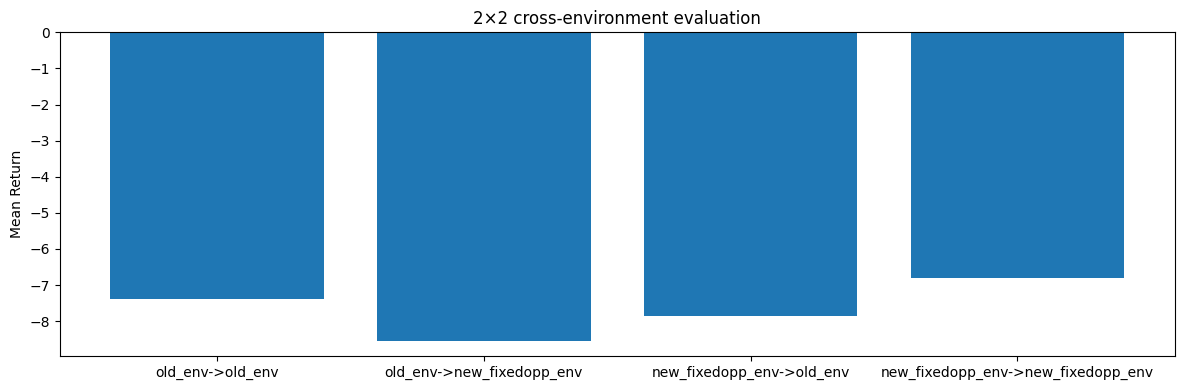

In [31]:
labels = [f"{tr}->{te}" for tr, te in zip(cross_2x2["train_env"], cross_2x2["test_env"])]
values = cross_2x2["mean_return"].values

plt.figure(figsize=(12, 4))
plt.bar(labels, values)
plt.ylabel("Mean Return")
plt.title("2×2 cross-environment evaluation")
plt.tight_layout()
plt.show()

In [32]:
with open("results/cross_eval/old_on_new_5seed_aggregate.json", "r") as f:
    old_on_new = json.load(f)

with open("results/cross_eval/new_on_old_5seed_aggregate.json", "r") as f:
    new_on_old = json.load(f)

old_on_new_summary = old_on_new["mean_of_mean_returns"]
new_on_old_summary = new_on_old["mean_of_mean_returns"]

pd.DataFrame([
    {"direction": "old -> new", "mean_return": old_on_new_summary},
    {"direction": "new -> old", "mean_return": new_on_old_summary},
])

,direction,mean_return
0,old -> new,-8.5408
1,new -> old,-7.8450


The cross-environment results lead to three clear conclusions:

1. **The original-environment specialist does not transfer well to the harder fixed-opponent environment.**
2. **Retraining in the harder environment is necessary and significantly improves performance there.**
3. **The gain is mainly environment-specific adaptation, not universal improvement**, because the fixed-opponent-trained model does not outperform the old specialist when transferred back to the original random-opponent environment.

## 6. Final takeaway

Across the whole project, the main lessons are:

- Building a **correct and reproducible environment** is essential before comparing RL algorithms.
- In this task, **representation design matters more than simply switching between standard RL methods**.
- Row symmetry is a key structural property of the game, and exploiting it through **Row DeepSets** improves performance.
- When the opponent distribution changes, the optimal policy also changes: stronger fixed opponents induce a different solution, and retraining becomes necessary.

## 7. Reproducibility and how to run

This notebook is designed as a **lightweight demo and results viewer**.

It does **not** retrain all models by default, because the full experiments involve multiple seeds and can take a non-trivial amount of time. Instead, the notebook:
- demonstrates the environments,
- loads final summarized results from `results/`,
- and shows how to reproduce the main experiments through the provided scripts.

The project code is organized as follows:

- `src/sixnimmt_env/`  
  environment definitions and opponent policies
- `scripts/`  
  training and evaluation scripts
- `checkpoints/`  
  trained weights (demo checkpoints, frozen opponents, and full runs)
- `results/`  
  summarized tables used in the report and in this notebook

### Installation

From the repository root, a minimal setup is:

```bash
pip install -r requirements.txt
pip install -e .
```

The editable installation relies on the provided pyproject.toml and allows imports such as:

```python
from sixnimmt_env import SixQuiPrendEnv
```

### Main experiment commands

Below are the main commands used in this project.

#### 1. Original environment: QRDQN + Row DeepSets
Train:
```bash
python scripts/train_qrdqn_row_deepsets.py ...
```
Evaluate:
```bash
python scripts/eval_qrdqn_row_deepsets.py ...
```

#### Hader fixed-opponent environment
Train:
```bash
python scripts/train_qrdqn_row_deepsets_fixed_opp.py \
  --ppo1_run_dir checkpoints/frozen_opponents/ppo_seed1 \
  --ppo2_run_dir checkpoints/frozen_opponents/ppo_seed2 \
  --heuristic_run_dir checkpoints/frozen_opponents/heuristic_seed1
```
Evaluate:
```bash
python scripts/eval_qrdqn_row_deepsets_fixed_opp.py ...
```
#### 3. Cross-environment evaluation

Old model on fixed-opponent environment:
```bash
python scripts/eval_old_model_on_fixedopp_env.py \
  --run_dir checkpoints/outputs/qrdqn_rowdeepsets_seed4 \
  --ppo1_run_dir checkpoints/frozen_opponents/ppo_seed1 \
  --ppo2_run_dir checkpoints/frozen_opponents/ppo_seed2 \
  --heuristic_run_dir checkpoints/frozen_opponents/heuristic_seed1
```
Fixed-opponent-trained model on original environment:
```bash
python scripts/eval_fixedopp_model_on_old_env.py \
  --run_dir checkpoints/outputs/qrdqn_rowdeepsets_fixedopp_seed2
```

### Baseline scripts

For completeness, the repository also includes the scripts used for the other baselines discussed in the report:

- `train_maskable_ppo.py` / `eval_policy.py`
- `train_heuristic_rl.py` / `eval_heuristic_rl.py`
- `train_value_based.py` / `eval_value_based.py`

These correspond to the old-environment comparisons summarized in:

- `results/old_env/all_methods_5seed_summary.csv`

### Results used in this notebook

The notebook mainly reads the following final summary files:

- `results/old_env/all_methods_5seed_summary.csv`
- `results/old_env/qrdqn_rowdeepsets_5seed_aggregate.json`
- `results/ablation/ablation_aggregate.csv`
- `results/ablation/ablation_main_effects.csv`
- `results/ablation/ablation_pairwise_interactions.csv`
- `results/new_env/qrdqn_rowdeepsets_fixedopp_5seed_aggregate.json`
- `results/cross_eval/old_on_new_5seed_aggregate.json`
- `results/cross_eval/new_on_old_5seed_aggregate.json`
- `results/cross_eval/summary_2x2.csv`

So even without rerunning training, the final reported conclusions can be inspected directly from the repository outputs.

### Final note

The project is intentionally split into:
- reusable Python modules for the environments,
- script-based experiment pipelines,
- and a notebook for demonstration and result inspection.

This makes the repository easier to read and avoids duplicating heavy training logic inside the notebook.